In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [182]:
mel_data = (
    pd.read_excel('Melbourne01.xlsx')
    .rename(columns=lambda col: col.strip())
)
mel_data.head()

,Year,Month,Day,Hour,Min,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),gamma,Calculated Dew Pt Temp (degrees C),E (hPa),Calculated Apparent Temp (degrees C)
0,2011,1,1.0,0.0,4.0,24.8,0.0,14.0,51.0,SE,11,13.0,1007.4,0,0.969609,14.1,15.916676,23.9
1,2011,1,1.0,0.0,14.0,24.8,0.0,13.3,48.0,SE,11,11.0,1007.5,0,0.908985,13.2,14.980401,23.6
2,2011,1,1.0,0.0,24.0,24.9,0.0,13.3,48.0,SE,11,13.0,1007.5,0,0.915025,13.2,15.069879,23.7
3,2011,1,1.0,0.0,34.0,24.7,0.0,13.4,49.0,SE,11,11.0,1007.4,0,0.923560,13.4,15.201624,23.6
4,2011,1,1.0,0.0,44.0,24.1,0.0,13.3,51.0,ESE,9,9.0,1007.3,0,0.927209,13.4,15.264860,23.4


# Data Cleaning and Preprocessing

In [ ]:
#Except for "Wind Direction", all columns should be numeric. Convert them to numeric types, coercing errors to NaN.

numeric_cols = mel_data.columns.drop("Wind Direction")

mel_data[numeric_cols] = mel_data[numeric_cols].apply(
    pd.to_numeric, errors='coerce'
)

mel_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 505355 entries, 0 to 505354
Data columns (total 18 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Year                                  504606 non-null  float64
 1   Month                                 504723 non-null  float64
 2   Day                                   504723 non-null  float64
 3   Hour                                  504723 non-null  float64
 4   Min                                   504723 non-null  float64
 5   Air Temp (degrees C)                  504723 non-null  float64
 6   Apparent Temp (degrees C)             504723 non-null  float64
 7   Dew Pt Temp (degrees C)               504723 non-null  float64
 8   Humidity (%)                          504723 non-null  float64
 9   Wind Direction                        504723 non-null  object 
 10  Wind Speed (km/h)                     504590 non-null  float64
 11  

In [ ]:
# Calculate the percentage of missing values in the dataset (validation of NaN dropping)

(len(mel_data)-len(mel_data.dropna()))/len(mel_data)

0.0016918799655687585

In [185]:
mel_data = mel_data.dropna()
mel_data

,Year,Month,Day,Hour,Min,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),gamma,Calculated Dew Pt Temp (degrees C),E (hPa),Calculated Apparent Temp (degrees C)
0,2011.0,1.0,1.0,0.0,4.0,24.8,0.0,14.0,51.0,SE,11.0,13.0,1007.4,0.0,0.969609,14.1,15.916676,23.9
1,2011.0,1.0,1.0,0.0,14.0,24.8,0.0,13.3,48.0,SE,11.0,11.0,1007.5,0.0,0.908985,13.2,14.980401,23.6
2,2011.0,1.0,1.0,0.0,24.0,24.9,0.0,13.3,48.0,SE,11.0,13.0,1007.5,0.0,0.915025,13.2,15.069879,23.7
3,2011.0,1.0,1.0,0.0,34.0,24.7,0.0,13.4,49.0,SE,11.0,11.0,1007.4,0.0,0.923560,13.4,15.201624,23.6
4,2011.0,1.0,1.0,0.0,44.0,24.1,0.0,13.3,51.0,ESE,9.0,9.0,1007.3,0.0,0.927209,13.4,15.264860,23.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
505350,2022.0,3.0,8.0,15.0,40.0,18.6,16.0,13.2,71.0,SSW,39.0,46.0,1018.0,0.0,0.917431,13.3,15.179146,12.0
505351,2022.0,3.0,8.0,15.0,50.0,18.7,18.5,13.6,72.0,SSW,35.0,46.0,1017.9,0.0,0.937732,13.6,15.489394,13.0
505352,2022.0,3.0,8.0,16.0,0.0,18.9,17.6,13.7,72.0,SSW,35.0,41.0,1017.8,0.0,0.950348,13.8,15.683896,13.3
505353,2022.0,3.0,8.0,16.0,10.0,19.2,18.3,13.8,71.0,S,32.0,35.0,1017.8,0.0,0.955250,13.9,15.757716,14.2


In [189]:
# Datetime converting

mel_data.rename(columns={'Min': 'Minute'}, inplace=True)

mel_data['Datetime'] = pd.to_datetime(
    mel_data[['Year','Month','Day','Hour','Minute']]
)
mel_data.sort_values('Datetime', inplace=True)
mel_data.drop(columns=['Year','Month','Day','Hour','Minute'], inplace=True)
mel_data

,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),gamma,Calculated Dew Pt Temp (degrees C),E (hPa),Calculated Apparent Temp (degrees C),Datetime
0,24.8,0.0,14.0,51.0,SE,11.0,13.0,1007.4,0.0,0.969609,14.1,15.916676,23.9,2011-01-01 00:04:00
1,24.8,0.0,13.3,48.0,SE,11.0,11.0,1007.5,0.0,0.908985,13.2,14.980401,23.6,2011-01-01 00:14:00
2,24.9,0.0,13.3,48.0,SE,11.0,13.0,1007.5,0.0,0.915025,13.2,15.069879,23.7,2011-01-01 00:24:00
3,24.7,0.0,13.4,49.0,SE,11.0,11.0,1007.4,0.0,0.923560,13.4,15.201624,23.6,2011-01-01 00:34:00
4,24.1,0.0,13.3,51.0,ESE,9.0,9.0,1007.3,0.0,0.927209,13.4,15.264860,23.4,2011-01-01 00:44:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
505350,18.6,16.0,13.2,71.0,SSW,39.0,46.0,1018.0,0.0,0.917431,13.3,15.179146,12.0,2022-03-08 15:40:00
505351,18.7,18.5,13.6,72.0,SSW,35.0,46.0,1017.9,0.0,0.937732,13.6,15.489394,13.0,2022-03-08 15:50:00
505352,18.9,17.6,13.7,72.0,SSW,35.0,41.0,1017.8,0.0,0.950348,13.8,15.683896,13.3,2022-03-08 16:00:00
505353,19.2,18.3,13.8,71.0,S,32.0,35.0,1017.8,0.0,0.955250,13.9,15.757716,14.2,2022-03-08 16:10:00


In [190]:
mel_data.columns

Index(['Air Temp (degrees C)', 'Apparent Temp (degrees C)',
       'Dew Pt Temp (degrees C)', 'Humidity (%)', 'Wind Direction',
       'Wind Speed (km/h)', 'Wind Gust  (km/h)', 'MSLP (hPa)',
       'Rainfall since 9 am (mm)', 'gamma',
       'Calculated Dew Pt Temp (degrees C)', 'E (hPa)',
       'Calculated Apparent Temp (degrees C)', 'Datetime'],
      dtype='object')

In [191]:
# For continuous columns, identify outliers using the 2.5th and 97.5th percentiles (fixed quantile trimming).
# Interpolate with the average of their immediate neighbors (interpolation).

continuous_cols = [
    'Air Temp (degrees C)',
    'Apparent Temp (degrees C)',
    'Dew Pt Temp (degrees C)',
    'Humidity (%)',
    'Wind Speed (km/h)',
    'MSLP (hPa)',
    'E (hPa)',
    'gamma',
    'Calculated Dew Pt Temp (degrees C)',
    'Calculated Apparent Temp (degrees C)'
]

for col in continuous_cols:
    lower = mel_data[col].quantile(0.025)
    upper = mel_data[col].quantile(0.975)

    outlier = (mel_data[col] < lower) | (mel_data[col] > upper)

    mel_data.loc[outlier, col] = (mel_data[col].shift(1) + mel_data[col].shift(-1)) / 2

In [ ]:
# Visually check discontinuous columns

discontinuous_cols = mel_data.columns.difference(continuous_cols)
discontinuous_cols

Index(['Datetime', 'Rainfall since 9 am (mm)', 'Wind Direction',
       'Wind Gust  (km/h)'],
      dtype='object')

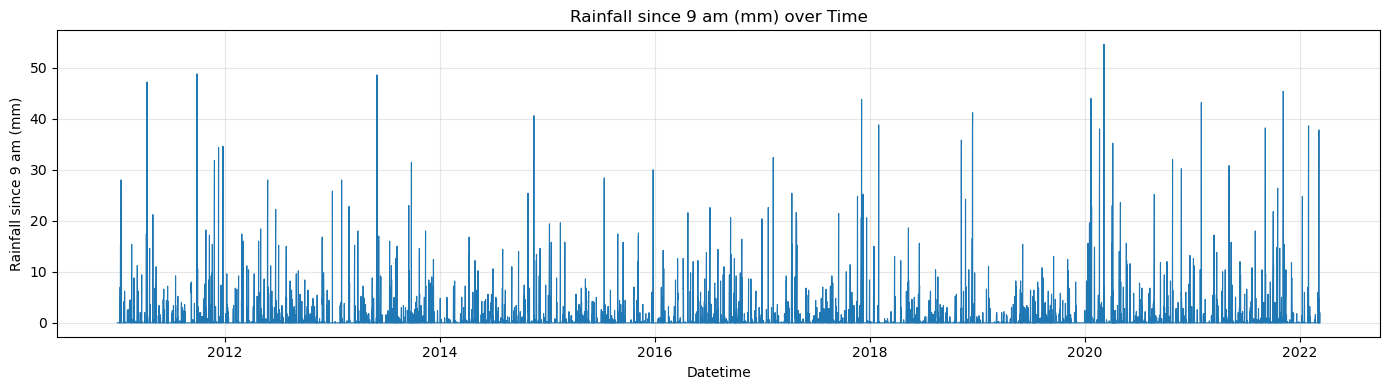

In [ ]:
# Valid rainfall data should be non-negative. Check for negative values in the "Rainfall since 9 am (mm)" column and handle them if necessary.

plt.figure(figsize=(14, 4))
plt.plot(mel_data['Datetime'], mel_data['Rainfall since 9 am (mm)'], linewidth=0.8)
plt.title('Rainfall since 9 am (mm) over Time')
plt.xlabel('Datetime')
plt.ylabel('Rainfall since 9 am (mm)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

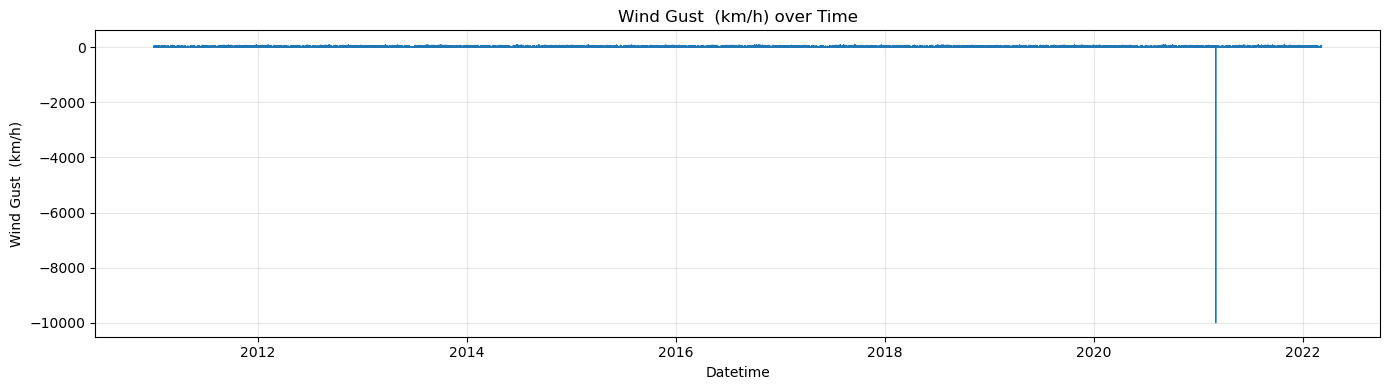

In [ ]:
# Valid wind gust data should be non-negative. Check for negative values in the "Wind Gust  (km/h)" column and handle them if necessary.

plt.figure(figsize=(14, 4))
plt.plot(mel_data['Datetime'], mel_data['Wind Gust  (km/h)'], linewidth=0.8)
plt.title('Wind Gust  (km/h) over Time')
plt.xlabel('Datetime')
plt.ylabel('Wind Gust  (km/h)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [198]:
len([mel_data['Wind Gust  (km/h)'] < 0])

1

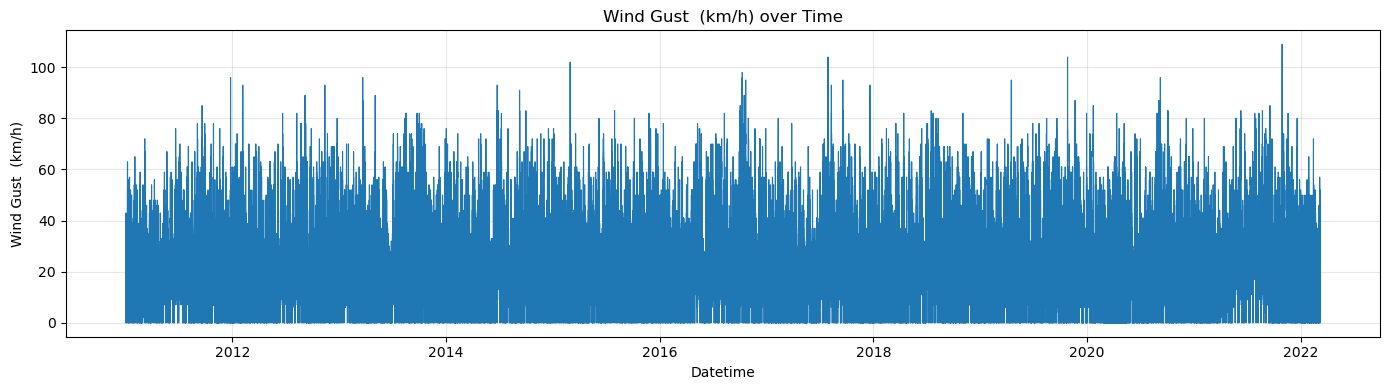

In [ ]:
mel_data = mel_data[mel_data['Wind Gust  (km/h)'] >= 0]

plt.figure(figsize=(14, 4))
plt.plot(mel_data['Datetime'], mel_data['Wind Gust  (km/h)'], linewidth=0.8)
plt.title('Wind Gust  (km/h) over Time')
plt.xlabel('Datetime')
plt.ylabel('Wind Gust  (km/h)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Valid wind direction data should not be numeric values. Check for unique values in the "Wind Direction" column to identify any invalid entries.

mel_data['Wind Direction'].unique()

array(['SE', 'ESE', 'NE', 'NNE', 'ENE', 'W', 'N', 'SW', 'SSE', 'S', 'SSW',
       'WSW', 'NW', 'WNW', 'NNW', 'E', 'CALM', 1016.6, 1016.9, 1017,
       1017.4, 1026, 1026.1, 1025.3, 1024.2, 1029.6, 1003.3, 1008.2, 1019,
       1015.5, 1014.2, 1015.9, 1016.2, 1016.1, 1014.1, 1014, 1013.6,
       1012.7, 1013.1, 1014.4, 1014.6, 1015.6, 1015.8, 1016.7, 1017.2,
       1016, 1017.8, 1019.5, 1019.8, 1019.9, 1020.4, 1021, 1021.2, 1021.7,
       1021.9, 1022.3, 1022.7, 1004.5, 1022, 1010.3, 1012, 1010.8],
      dtype=object)

In [203]:
valid_dr = ['SE', 'ESE', 'NE', 'NNE', 'ENE', 'W', 'N', 'SW', 'SSE', 'S', 'SSW', 'WSW', 'NW', 'WNW', 'NNW', 'E', 'CALM']
len(mel_data[~mel_data['Wind Direction'].isin(valid_dr)])

56

In [205]:
mel_data = mel_data[mel_data['Wind Direction'].isin(valid_dr)]
mel_data['Wind Direction'].unique()

array(['SE', 'ESE', 'NE', 'NNE', 'ENE', 'W', 'N', 'SW', 'SSE', 'S', 'SSW',
       'WSW', 'NW', 'WNW', 'NNW', 'E', 'CALM'], dtype=object)

In [209]:
# One-hot encode the "Wind Direction" column and drop the original column.
# Even though circular encoding using sine and cosine can capture geometric relationships, 
# one-hot encoding is more interpretable for tree-based models and can still capture the necessary information without introducing complexity.

dummies=pd.get_dummies(mel_data['Wind Direction'], prefix='WindDir')
mel_data_oh = mel_data.join(dummies).drop(columns=['Wind Direction'])

mel_data_oh

,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),gamma,Calculated Dew Pt Temp (degrees C),...,WindDir_NNW,WindDir_NW,WindDir_S,WindDir_SE,WindDir_SSE,WindDir_SSW,WindDir_SW,WindDir_W,WindDir_WNW,WindDir_WSW
0,24.8,0.0,14.0,51.0,11.0,13.0,1007.4,0.0,0.969609,14.1,...,False,False,False,True,False,False,False,False,False,False
1,24.8,0.0,13.3,48.0,11.0,11.0,1007.5,0.0,0.908985,13.2,...,False,False,False,True,False,False,False,False,False,False
2,24.9,0.0,13.3,48.0,11.0,13.0,1007.5,0.0,0.915025,13.2,...,False,False,False,True,False,False,False,False,False,False
3,24.7,0.0,13.4,49.0,11.0,11.0,1007.4,0.0,0.923560,13.4,...,False,False,False,True,False,False,False,False,False,False
4,24.1,0.0,13.3,51.0,9.0,9.0,1007.3,0.0,0.927209,13.4,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
505350,18.6,16.0,13.2,71.0,39.0,46.0,1018.0,0.0,0.917431,13.3,...,False,False,False,False,False,True,False,False,False,False
505351,18.7,18.5,13.6,72.0,35.0,46.0,1017.9,0.0,0.937732,13.6,...,False,False,False,False,False,True,False,False,False,False
505352,18.9,17.6,13.7,72.0,35.0,41.0,1017.8,0.0,0.950348,13.8,...,False,False,False,False,False,True,False,False,False,False
505353,19.2,18.3,13.8,71.0,32.0,35.0,1017.8,0.0,0.955250,13.9,...,False,False,True,False,False,False,False,False,False,False


In [ ]:
# Daily Aggregation

wind_cols = [c for c in mel_data_oh.columns if c.startswith('WindDir_')]

daily_data = mel_data_oh.resample('D', on='Datetime').agg({
    **{col: 'mean' for col in wind_cols},
    'Air Temp (degrees C)': 'mean',
    'Humidity (%)': 'mean',
    'MSLP (hPa)': 'mean',
    'Wind Speed (km/h)': 'mean',
    'Wind Gust  (km/h)': 'max',
    'E (hPa)': 'mean',
    'Dew Pt Temp (degrees C)': 'mean',
    'Apparent Temp (degrees C)': 'mean',
    'Rainfall since 9 am (mm)': 'last'
})

daily_data['RainTomorrow'] = (daily_data['Rainfall since 9 am (mm)'].shift(-1) > 0)

daily_data

,WindDir_CALM,WindDir_E,WindDir_ENE,WindDir_ESE,WindDir_N,WindDir_NE,WindDir_NNE,WindDir_NNW,WindDir_NW,WindDir_S,...,Air Temp (degrees C),Humidity (%),MSLP (hPa),Wind Speed (km/h),Wind Gust (km/h),E (hPa),Dew Pt Temp (degrees C),Apparent Temp (degrees C),Rainfall since 9 am (mm),RainTomorrow
Datetime,,,,,,,,,,,,,,,,,,,,,
2011-01-01,0.00,0.000,0.038760,0.015504,0.007752,0.015504,0.007752,0.000000,0.023256,0.418605,...,19.651938,61.635659,1011.784496,14.325581,43.0,13.980619,12.004651,0.000000,0.0,False
2011-01-02,0.00,0.000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.632653,...,18.169388,52.153061,1016.310204,21.775510,39.0,10.760363,8.087755,0.000000,0.0,False
2011-01-03,0.00,0.000,0.000000,0.007692,0.000000,0.000000,0.000000,0.000000,0.000000,0.446154,...,16.583846,47.807692,1016.946154,24.469231,41.0,8.949827,5.462308,0.000000,0.0,False
2011-01-04,0.00,0.000,0.000000,0.000000,0.000000,0.000000,0.000000,0.007752,0.000000,0.255814,...,16.780620,60.007752,1012.396899,15.697674,37.0,11.376651,8.866667,0.000000,0.0,False
2011-01-05,0.00,0.000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.007752,0.418605,...,18.110853,66.565891,1010.086047,19.837209,37.0,13.699222,11.719380,0.000000,0.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-03-04,0.12,0.032,0.016000,0.016000,0.272000,0.024000,0.048000,0.064000,0.072000,0.056000,...,24.466000,66.504000,1009.955200,15.688000,46.0,18.990599,16.648400,25.397400,3.8,True
2022-03-05,0.00,0.000,0.015038,0.000000,0.007519,0.022556,0.000000,0.000000,0.007519,0.195489,...,19.320301,89.657895,1007.534586,19.406015,43.0,20.041684,17.524060,20.012030,1.2,False
2022-03-06,0.00,0.000,0.000000,0.000000,0.007692,0.000000,0.000000,0.000000,0.000000,0.000000,...,18.484615,79.038462,1015.901538,27.546154,57.0,16.718350,14.629423,17.083077,0.0,True


In [211]:
daily_data['RainTomorrow'].unique()

array([False,  True])

In [ ]:
# Lag Feature Creation for 3 days

lag_cols = [
    'Rainfall since 9 am (mm)',
    'Air Temp (degrees C)',
    'Humidity (%)',
    'MSLP (hPa)',
    'Wind Speed (km/h)',
    'Wind Gust  (km/h)',
    'E (hPa)',
    'Dew Pt Temp (degrees C)',
    'Apparent Temp (degrees C)'
]

max_lag = 3 

lag_daily = daily_data.copy()

for col in lag_cols:
    for lag in range(1, max_lag + 1):
        lag_daily[f"{col}_lag{lag}"] = lag_daily[col].shift(lag)

lag_daily = lag_daily.dropna()
lag_daily

,WindDir_CALM,WindDir_E,WindDir_ENE,WindDir_ESE,WindDir_N,WindDir_NE,WindDir_NNE,WindDir_NNW,WindDir_NW,WindDir_S,...,Wind Gust (km/h)_lag3,E (hPa)_lag1,E (hPa)_lag2,E (hPa)_lag3,Dew Pt Temp (degrees C)_lag1,Dew Pt Temp (degrees C)_lag2,Dew Pt Temp (degrees C)_lag3,Apparent Temp (degrees C)_lag1,Apparent Temp (degrees C)_lag2,Apparent Temp (degrees C)_lag3
Datetime,,,,,,,,,,,,,,,,,,,,,
2011-01-04,0.00,0.000,0.000000,0.000,0.000000,0.000000,0.000000,0.007752,0.000000,0.255814,...,43.0,8.949827,10.760363,13.980619,5.462308,8.087755,12.004651,0.000000,0.000000,0.000000
2011-01-05,0.00,0.000,0.000000,0.000,0.000000,0.000000,0.000000,0.000000,0.007752,0.418605,...,39.0,11.376651,8.949827,10.760363,8.866667,5.462308,8.087755,0.000000,0.000000,0.000000
2011-01-06,0.00,0.008,0.016000,0.016,0.136000,0.008000,0.032000,0.056000,0.088000,0.152000,...,41.0,13.699222,11.376651,8.949827,11.719380,8.866667,5.462308,0.000000,0.000000,0.000000
2011-01-07,0.00,0.000,0.000000,0.000,0.821705,0.000000,0.178295,0.000000,0.000000,0.000000,...,37.0,15.244087,13.699222,11.376651,13.362400,11.719380,8.866667,0.000000,0.000000,0.000000
2011-01-08,0.00,0.000,0.000000,0.000,0.567568,0.000000,0.081081,0.054054,0.040541,0.094595,...,37.0,14.627737,15.244087,13.699222,12.810078,13.362400,11.719380,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-03-04,0.12,0.032,0.016000,0.016,0.272000,0.024000,0.048000,0.064000,0.072000,0.056000,...,22.0,18.405996,20.218435,21.668813,16.234843,17.586822,18.817366,24.716339,25.256977,24.662405
2022-03-05,0.00,0.000,0.015038,0.000,0.007519,0.022556,0.000000,0.000000,0.007519,0.195489,...,37.0,18.990599,18.405996,20.218435,16.648400,16.234843,17.586822,25.397400,24.716339,25.256977
2022-03-06,0.00,0.000,0.000000,0.000,0.007692,0.000000,0.000000,0.000000,0.000000,0.000000,...,26.0,20.041684,18.990599,18.405996,17.524060,16.648400,16.234843,20.012030,25.397400,24.716339


# Modelling

In [215]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [216]:
model_df = lag_daily.copy()

y = model_df['RainTomorrow'].astype(int)
X = model_df.drop(columns=['RainTomorrow'])

In [ ]:
# TimeSeriesSplit for time-series data to prevent data leakage

tscv = TimeSeriesSplit(n_splits=5)

rf = RandomForestClassifier(
    random_state=42,
    class_weight='balanced'
)

param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [5, 10, None],
    'min_samples_leaf': [1, 3, 5],
    'max_features': ['sqrt', 'log2']
}

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=tscv,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X, y)

best_rf = grid.best_estimator_
print("Best params:", grid.best_params_)

Best params: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 400}


In [218]:
train_idx, test_idx = list(tscv.split(X))[-1]

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

best_rf.fit(X_train, y_train)

y_pred = best_rf.predict(X_test)
y_prob = best_rf.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.6794682422451994
Precision: 0.4819672131147541
Recall: 0.7135922330097088
F1: 0.5753424657534246
ROC-AUC: 0.7368128130604168


In [219]:
importances = pd.Series(best_rf.feature_importances_, index=X.columns)
print(importances.sort_values(ascending=False).head(20))

MSLP (hPa)                        0.146688
WindDir_SSE                       0.093924
Rainfall since 9 am (mm)          0.092776
WindDir_S                         0.083063
Wind Speed (km/h)                 0.039282
Wind Gust  (km/h)                 0.037963
WindDir_SSW                       0.036988
MSLP (hPa)_lag1                   0.030842
WindDir_N                         0.027627
WindDir_SE                        0.026309
WindDir_NNE                       0.018525
Apparent Temp (degrees C)         0.018072
WindDir_SW                        0.015864
MSLP (hPa)_lag3                   0.014381
Humidity (%)                      0.014372
WindDir_NNW                       0.014314
Apparent Temp (degrees C)_lag3    0.013884
Air Temp (degrees C)              0.013213
Wind Speed (km/h)_lag1            0.011989
E (hPa)                           0.011914
dtype: float64


In [222]:
import pandas as pd
import numpy as np

base_cols = [
    'Rainfall since 9 am (mm)',
    'Air Temp (degrees C)',
    'Humidity (%)',
    'MSLP (hPa)',
    'Wind Speed (km/h)',
    'Wind Gust  (km/h)',
    'E (hPa)',
    'Dew Pt Temp (degrees C)',
    'Apparent Temp (degrees C)'
]

def build_features(daily_data, max_lag):
    df = daily_data.copy()

    # --- lag features ---
    for col in base_cols:
        for lag in range(1, max_lag + 1):
            df[f"{col}_lag{lag}"] = df[col].shift(lag)

    # --- rolling window features (3d, 7d) ---
    for col in base_cols:
        df[f"{col}_roll3_mean"] = df[col].rolling(window=3).mean()
        df[f"{col}_roll7_mean"] = df[col].rolling(window=7).mean()
        df[f"{col}_roll3_max"]  = df[col].rolling(window=3).max()
        df[f"{col}_roll7_max"]  = df[col].rolling(window=7).max()

    # drop rows with NaN from lag/rolling
    df = df.dropna()

    y = df['RainTomorrow'].astype(int)
    X = df.drop(columns=['RainTomorrow'])

    return X, y

In [220]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score

def eval_rf_tscv(X, y, n_splits=5):
    tscv = TimeSeriesSplit(n_splits=n_splits)

    rf = RandomForestClassifier(
        n_estimators=400,
        max_depth=10,
        min_samples_leaf=3,
        max_features='sqrt',
        class_weight='balanced',
        random_state=42
    )

    f1_scores = []
    auc_scores = []

    # also keep last fold for threshold tuning later
    last_fold = None

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X), 1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        rf.fit(X_train, y_train)
        y_prob = rf.predict_proba(X_test)[:, 1]
        y_pred = (y_prob > 0.5).astype(int)

        f1 = f1_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_prob)

        f1_scores.append(f1)
        auc_scores.append(auc)

        last_fold = (X_train, X_test, y_train, y_test, y_prob)

    return {
        "mean_f1": np.mean(f1_scores),
        "mean_auc": np.mean(auc_scores),
        "last_fold": last_fold
    }

In [223]:
results = []

for max_lag in range(1, 8):
    X, y = build_features(daily_data, max_lag=max_lag)
    metrics = eval_rf_tscv(X, y, n_splits=5)

    results.append({
        "max_lag": max_lag,
        "mean_f1": metrics["mean_f1"],
        "mean_auc": metrics["mean_auc"]
    })

lag_results = pd.DataFrame(results)
print(lag_results)

/var/folders/q0/1kjs8s8d6fn65050zv_j1x7c0000gn/T/ipykernel_15202/533697502.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{col}_roll7_max"]  = df[col].rolling(window=7).max()


   max_lag   mean_f1  mean_auc
0        1  0.524799  0.729219
1        2  0.526350  0.731635
2        3  0.512193  0.731402
3        4  0.513634  0.730011
4        5  0.511976  0.730734
5        6  0.501901  0.730886
6        7  0.503469  0.732513


In [224]:
thresholds = np.linspace(0.1, 0.9, 17)

rows = []
for thr in thresholds:
    y_pred_thr = (y_prob > thr).astype(int)
    f1 = f1_score(y_test, y_pred_thr)
    prec = precision_score(y_test, y_pred_thr)
    rec = recall_score(y_test, y_pred_thr)
    rows.append({
        "threshold": thr,
        "f1": f1,
        "precision": prec,
        "recall": rec
    })

thr_df = pd.DataFrame(rows)
print(thr_df.sort_values('f1', ascending=False).head(10))

    threshold        f1  precision    recall
8        0.50  0.575342   0.481967  0.713592
7        0.45  0.566494   0.439678  0.796117
6        0.40  0.558642   0.409502  0.878641
9        0.55  0.545455   0.512821  0.582524
5        0.35  0.526171   0.367308  0.927184
4        0.30  0.508816   0.343537  0.980583
10       0.60  0.496084   0.536723  0.461165
3        0.25  0.486874   0.322785  0.990291
2        0.20  0.471936   0.308846  1.000000
0        0.10  0.466591   0.304284  1.000000


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [225]:
import pandas as pd
import numpy as np

base_cols = [
    'Rainfall since 9 am (mm)',
    'Air Temp (degrees C)',
    'Humidity (%)',
    'MSLP (hPa)',
    'Wind Speed (km/h)',
    'Wind Gust  (km/h)',
    'E (hPa)',
    'Dew Pt Temp (degrees C)',
    'Apparent Temp (degrees C)'
]

def build_features_gb(daily_data, max_lag=3):
    df = daily_data.copy()

    # --- lag features ---
    for col in base_cols:
        for lag in range(1, max_lag + 1):
            df[f"{col}_lag{lag}"] = df[col].shift(lag)

    # --- rolling features ---
    for col in base_cols:
        df[f"{col}_roll3_mean"] = df[col].rolling(3).mean()
        df[f"{col}_roll7_mean"] = df[col].rolling(7).mean()
        df[f"{col}_roll3_max"]  = df[col].rolling(3).max()
        df[f"{col}_roll7_max"]  = df[col].rolling(7).max()
        df[f"{col}_roll3_std"]  = df[col].rolling(3).std()
        df[f"{col}_roll7_std"]  = df[col].rolling(7).std()

    df = df.dropna()

    y = df['RainTomorrow'].astype(int)
    X = df.drop(columns=['RainTomorrow'])

    return X, y

In [226]:
from xgboost import XGBClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score

def eval_xgb_tscv(X, y, n_splits=5):
    tscv = TimeSeriesSplit(n_splits=n_splits)

    xgb = XGBClassifier(
        n_estimators=500,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        scale_pos_weight=(y.value_counts()[0] / y.value_counts()[1]),  # imbalance handling
        random_state=42
    )

    f1_scores = []
    auc_scores = []
    last_fold = None

    for train_idx, test_idx in tscv.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        xgb.fit(X_train, y_train)
        y_prob = xgb.predict_proba(X_test)[:, 1]
        y_pred = (y_prob > 0.5).astype(int)

        f1_scores.append(f1_score(y_test, y_pred))
        auc_scores.append(roc_auc_score(y_test, y_prob))

        last_fold = (X_train, X_test, y_train, y_test, y_prob)

    return {
        "mean_f1": np.mean(f1_scores),
        "mean_auc": np.mean(auc_scores),
        "last_fold": last_fold,
        "model": xgb
    }

In [227]:
X, y = build_features_gb(daily_data, max_lag=3)
metrics = eval_xgb_tscv(X, y)

print("XGBoost Mean F1:", metrics["mean_f1"])
print("XGBoost Mean AUC:", metrics["mean_auc"])

XGBoost Mean F1: 0.47734049699061193
XGBoost Mean AUC: 0.7089428858217928


In [228]:
import pandas as pd

lag_cols = [
    'Rainfall since 9 am (mm)',
    'Air Temp (degrees C)',
    'Humidity (%)',
    'MSLP (hPa)',
    'Wind Speed (km/h)',
    'Wind Gust  (km/h)',
    'E (hPa)',
    'Dew Pt Temp (degrees C)',
    'Apparent Temp (degrees C)'
]

def build_lag3(daily_data):
    df = daily_data.copy()

    # 3‑day lag window
    for col in lag_cols:
        for lag in range(1, 4):
            df[f"{col}_lag{lag}"] = df[col].shift(lag)

    # remove rows with NaN from lagging
    df = df.dropna()

    y = df['RainTomorrow'].astype(int)
    X = df.drop(columns=['RainTomorrow'])

    return X, y


In [229]:
from xgboost import XGBClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score
import numpy as np

def eval_xgb_tscv(X, y, n_splits=5):
    tscv = TimeSeriesSplit(n_splits=n_splits)

    xgb = XGBClassifier(
        n_estimators=500,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        scale_pos_weight=(y.value_counts()[0] / y.value_counts()[1]),
        random_state=42
    )

    f1_scores = []
    auc_scores = []
    last_fold = None

    for train_idx, test_idx in tscv.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        xgb.fit(X_train, y_train)
        y_prob = xgb.predict_proba(X_test)[:, 1]
        y_pred = (y_prob > 0.5).astype(int)

        f1_scores.append(f1_score(y_test, y_pred))
        auc_scores.append(roc_auc_score(y_test, y_prob))

        last_fold = (X_train, X_test, y_train, y_test, y_prob)

    return {
        "mean_f1": np.mean(f1_scores),
        "mean_auc": np.mean(auc_scores),
        "last_fold": last_fold,
        "model": xgb
    }


In [230]:
X, y = build_lag3(daily_data)
metrics = eval_xgb_tscv(X, y)

print("XGBoost Mean F1:", metrics["mean_f1"])
print("XGBoost Mean AUC:", metrics["mean_auc"])

XGBoost Mean F1: 0.5029748778543016
XGBoost Mean AUC: 0.710736034772481
